# Задача 8 
## Сравнение методов классификации


# Загрузка данных

In [31]:

import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(url, sep=';')

# Первичный анализ данных
print(data.head())  # Просмотр первых нескольких строк данных
print(data.info())  # Информация о типах данных и наличии пропущенных значений
print(data.describe())  # Статистические характеристики данных

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

## Визуализация распределения оценок вин

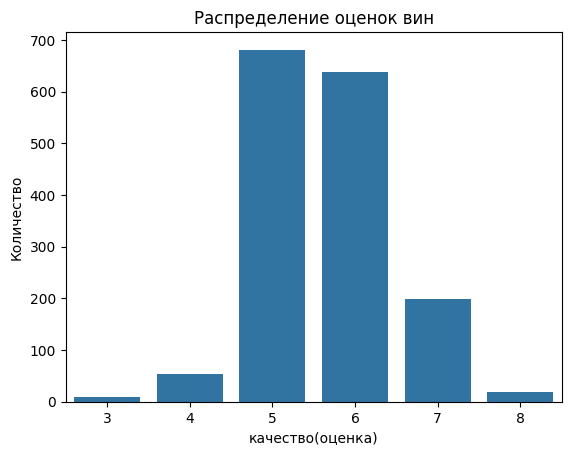

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='quality', data=data)
plt.title('Распределение оценок вин')
plt.xlabel('качество(оценка)')
plt.ylabel('Количество')
plt.show()

## Преобразуем в бинарную классификацию: хорошее/плохое вино


Бинарная классификация:
0 (плохое вино): 744 образцов
1 (хорошее вино): 855 образцов
Доля хорошего вина: 53.47%


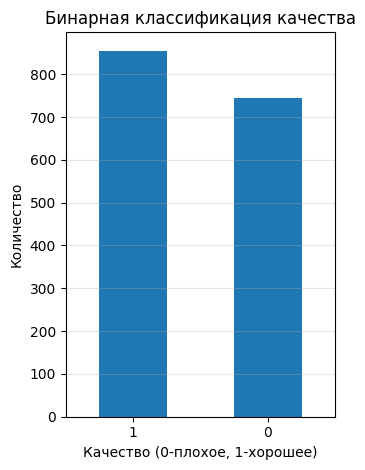

In [33]:
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 6 else 0)

print(f"\nБинарная классификация:")
print(f"0 (плохое вино): {(data['quality'] == 0).sum()} образцов")
print(f"1 (хорошее вино): {(data['quality'] == 1).sum()} образцов")
print(f"Доля хорошего вина: {data['quality'].mean():.2%}")

plt.subplot(1, 2, 2)
data['quality'].value_counts().plot(kind='bar')
plt.title('Бинарная классификация качества')
plt.xlabel('Качество (0-плохое, 1-хорошее)')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Гистограммы распределения признаков

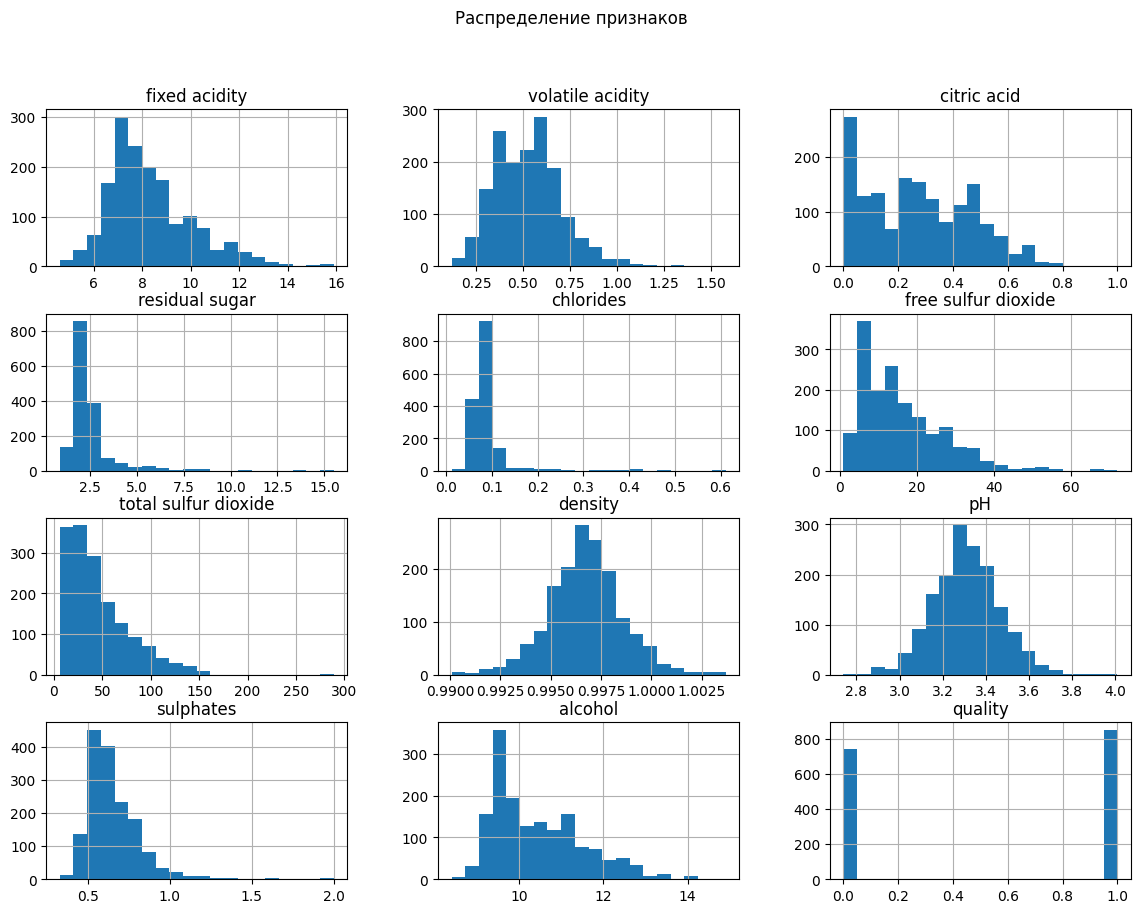

In [34]:
data.hist(bins=20, figsize=(14, 10))
plt.suptitle('Распределение признаков')
plt.show()

## Парные графики для визуализации взаимосвязей между признаками

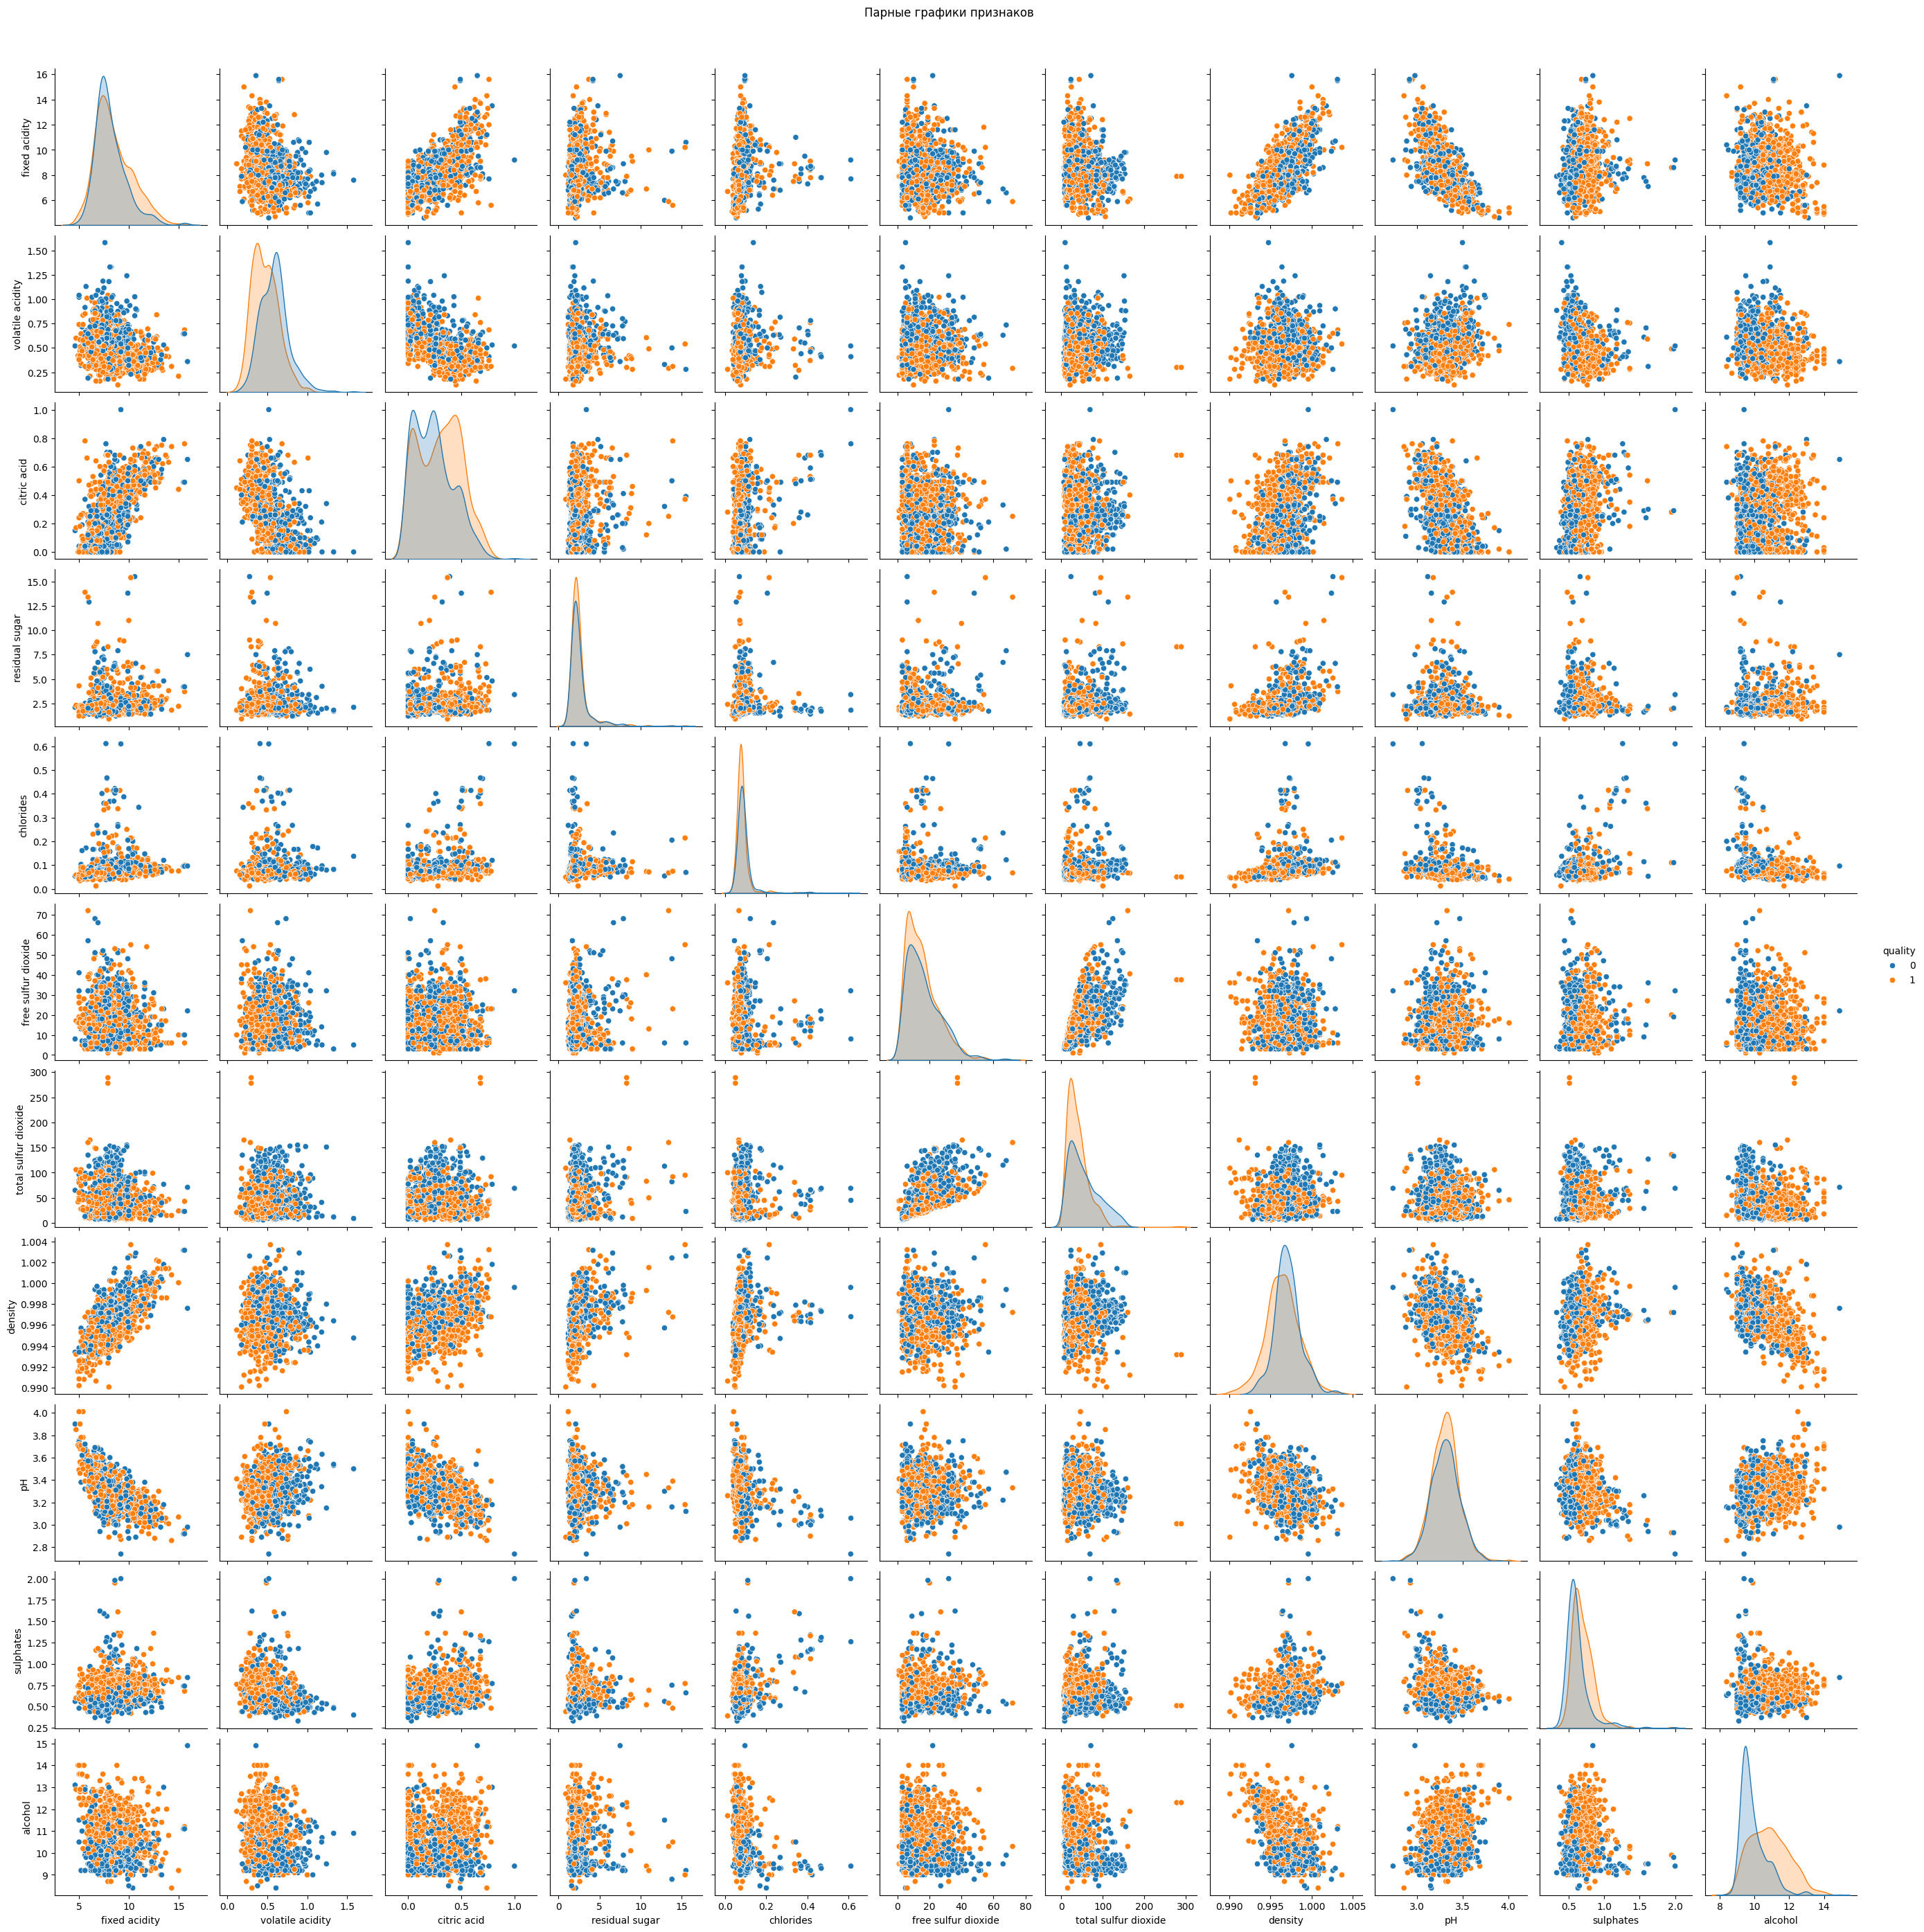

In [35]:
sns.pairplot(data, hue='quality')
plt.suptitle('Парные графики признаков', y=1.02)
plt.show()

## Корреляционная матрица для анализа линейных зависимостей между признаками

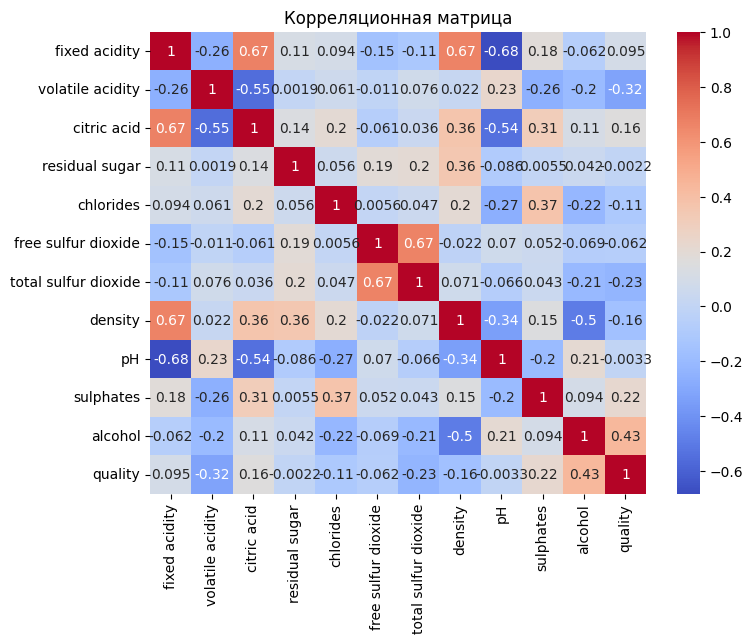

In [36]:
correlation_matrix = data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

## Преобразование данных, их проверка и масштабирование

In [37]:
# Преобразование данных
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Проверка пропущенных значений
display(data.isnull().sum())

# Разделение данных на обучающую и тестовую выборки
X = data.drop('quality', axis=1)  # Признаки
y = data['quality']  # Целевая переменная

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование данных для улучшения производительности моделей
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [38]:
# Преобразование данных
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Разделение данных на обучающую и тестовую выборки
X = data.drop('quality', axis=1)  # Признаки
y = data['quality']  # Целевая переменная

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование данных для улучшения производительности моделей
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Проверка размеров выборок
print(f"Размер обучающей выборки (признаки): {X_train_scaled.shape}")
print(f"Размер обучающей выборки (целевая переменная): {y_train.shape}")
print(f"Размер тестовой выборки (признаки): {X_test_scaled.shape}")
print(f"Размер тестовой выборки (целевая переменная): {y_test.shape}")

# Проверка первых нескольких строк масштабированных данных
print("\nПервые несколько строк масштабированных данных:")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())

# Проверка средних и стандартных отклонений масштабированных данных
print("\nСредние и стандартные отклонения масштабированных данных:")
display(pd.DataFrame(X_train_scaled, columns=X.columns).describe().loc[['mean', 'std']])

Размер обучающей выборки (признаки): (1279, 11)
Размер обучающей выборки (целевая переменная): (1279,)
Размер тестовой выборки (признаки): (320, 11)
Размер тестовой выборки (целевая переменная): (320,)

Первые несколько строк масштабированных данных:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.218332,0.889712,0.192092,0.309726,-0.049642,0.691007,1.042934,1.846696,1.093500,0.458223,1.123177
1,-1.290166,-1.788783,0.652753,-0.805080,-0.455214,2.388473,3.593870,-3.004491,-0.400439,-0.401197,1.408272
2,1.494753,-0.784347,1.011045,-0.526378,0.599272,-0.957960,-0.991742,0.768655,-0.075669,0.515517,-0.587390
3,0.276351,0.861811,-0.063831,-0.665729,-0.009085,0.012020,-0.718427,0.089488,0.054238,-1.088733,-0.967516
4,0.044274,2.814880,-0.626861,2.399985,-0.313264,-0.472970,0.222990,1.199871,0.379008,-0.974144,-0.492358



Средние и стандартные отклонения масштабированных данных:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
mean,-1.111091e-16,4.117981e-16,1.263866e-16,1.527750e-17,-1.041648e-16,-7.638751e-17,-7.569308e-17,2.559398e-14,-1.358309e-15,4.152703e-16,4.777692e-16
std,1.000391e+00,1.000391e+00,1.000391e+00,1.000391e+00,1.000391e+00,1.000391e+00,1.000391e+00,1.000391e+00,1.000391e+00,1.000391e+00,1.000391e+00


# Обучение моделей с использованием библиотечных реализаций

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Логистическая регрессия
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)

# SVM
svm = SVC()
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# Оценка моделей
models = {
    'Logistic Regression': (y_pred_log_reg, log_reg),
    'SVM': (y_pred_svm, svm),
    'Random Forest': (y_pred_rf, rf),
    'KNN': (y_pred_knn, knn)
}

for name, (y_pred, model) in models.items():
    print(f'{name}:\n{classification_report(y_test, y_pred)}\n')

Logistic Regression:
              precision    recall  f1-score   support

           0       0.69      0.74      0.72       141
           1       0.79      0.74      0.76       179

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74      0.74      0.74       320


SVM:
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       141
           1       0.81      0.77      0.79       179

    accuracy                           0.77       320
   macro avg       0.77      0.77      0.77       320
weighted avg       0.77      0.77      0.77       320


Random Forest:
              precision    recall  f1-score   support

           0       0.76      0.77      0.76       141
           1       0.82      0.80      0.81       179

    accuracy                           0.79       320
   macro avg       0.79      0.79      0.79       320
weighted avg       0.79      0.

## Построение confusion matrices для всех моделей

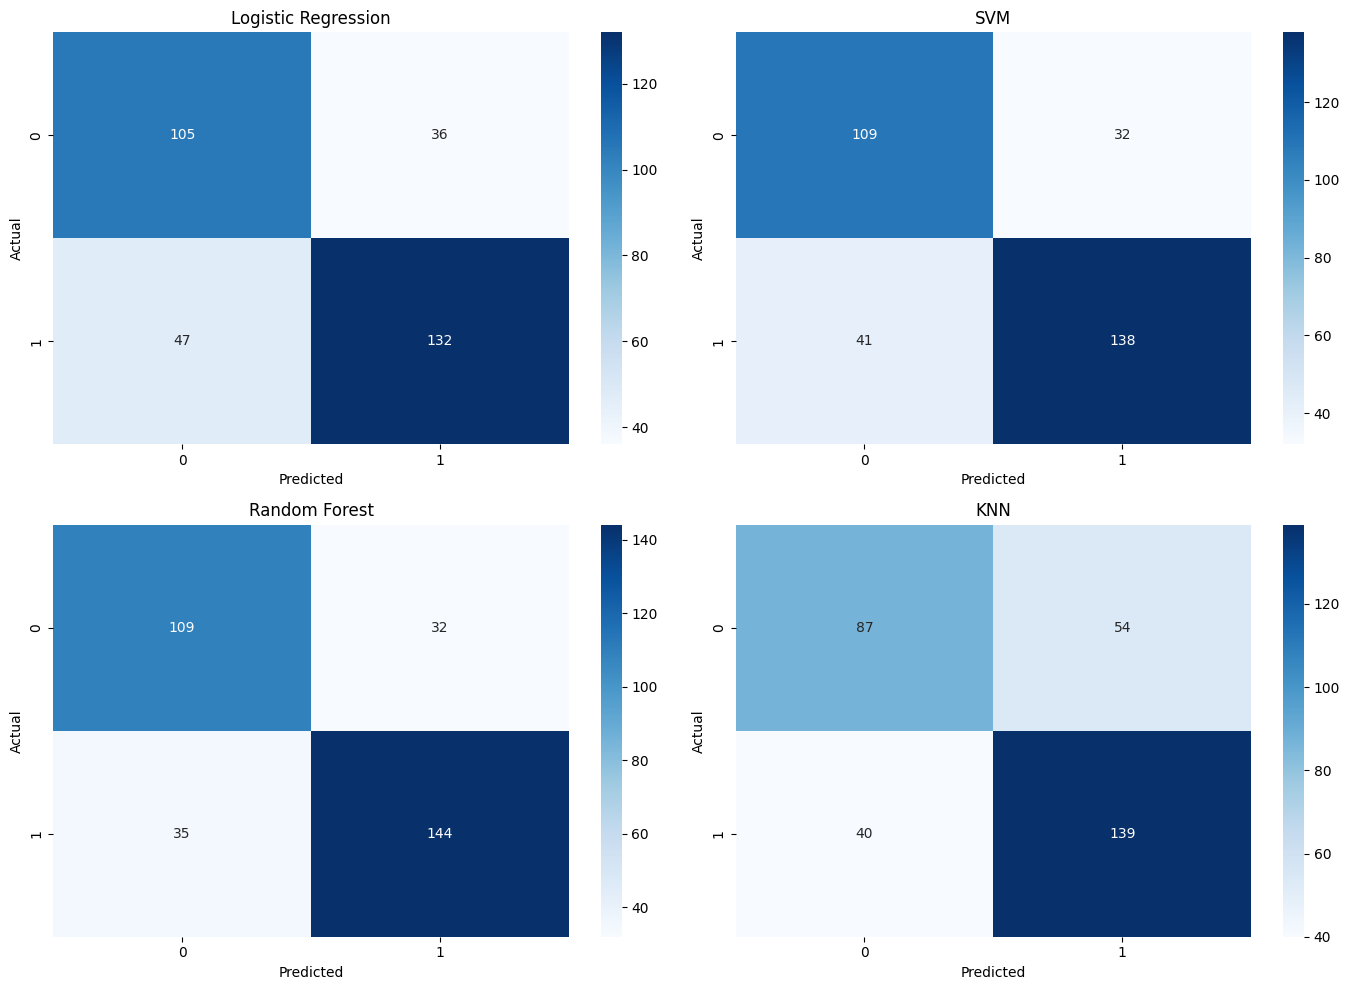

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, (y_pred, _)) in zip(axes.ravel(), models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [41]:
## Подбор гиперпараметров для SVM

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01,

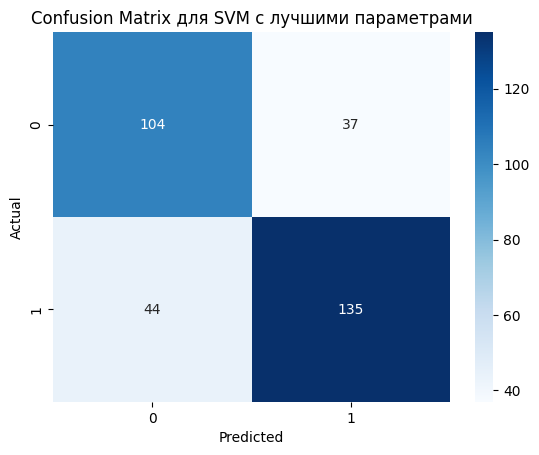

In [42]:
from sklearn.model_selection import GridSearchCV

# Определяем сетку гиперпараметров для SVM
param_grid = {'C': [0.1, 1, 10], 'gamma': [1, 0.1, 0.01], 'kernel': ['rbf']}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)
grid.fit(X_train_scaled, y_train)
print(f'Лучшие параметры для SVM: {grid.best_params_}')

# Обучение модели с лучшими параметрами
best_svm = grid.best_estimator_
y_pred_best_svm = best_svm.predict(X_test_scaled)

# Оценка модели с лучшими параметрами
print(f'Оценка SVM с лучшими параметрами:\n{classification_report(y_test, y_pred_best_svm)}\n')

# Confusion matrix для лучшей модели SVM
cm_best_svm = confusion_matrix(y_test, y_pred_best_svm)
sns.heatmap(cm_best_svm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix для SVM с лучшими параметрами')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Реализация собственного метода классификации (KNN)
##    Обучение и оценка собственной модели
##    Confusion matrix для собственной модели
##    Подбор гиперпараметра для своей модели

Custom KNN:
              precision    recall  f1-score   support

           0       0.68      0.63      0.65       141
           1       0.72      0.77      0.74       179

    accuracy                           0.71       320
   macro avg       0.70      0.70      0.70       320
weighted avg       0.70      0.71      0.70       320




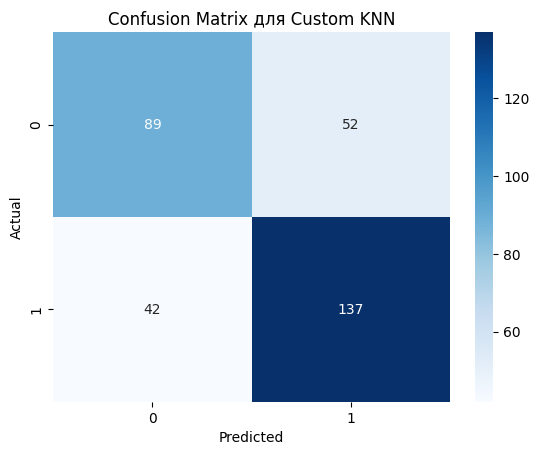

In [43]:
import numpy as np

class CustomKNN:
    def __init__(self, k=3):
        self.k = k
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = np.array(y)  # Преобразуем y_train в массив NumPy
    
    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)
    
    def _predict(self, x):
        distances = [np.linalg.norm(x - x_train) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_common = max(set(k_nearest_labels), key=k_nearest_labels.count)
        return most_common

# Обучение и оценка собственной модели
custom_knn = CustomKNN(k=3)
custom_knn.fit(X_train_scaled, y_train)
y_pred_custom_knn = custom_knn.predict(X_test_scaled)

print(f'Custom KNN:\n{classification_report(y_test, y_pred_custom_knn)}\n')

# Confusion matrix для собственной модели
cm_custom_knn = confusion_matrix(y_test, y_pred_custom_knn)
sns.heatmap(cm_custom_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix для Custom KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Оптимальное значение k: 1
Custom KNN с оптимальным k:
              precision    recall  f1-score   support

           0       0.74      0.68      0.71       141
           1       0.76      0.81      0.79       179

    accuracy                           0.75       320
   macro avg       0.75      0.75      0.75       320
weighted avg       0.75      0.75      0.75       320




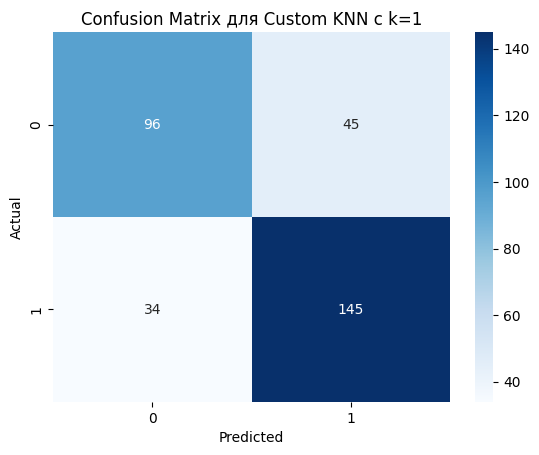

In [44]:
# Подбор гиперпараметра k для собственной модели KNN
from sklearn.metrics import accuracy_score

k_values = range(1, 21)
accuracies = []

for k in k_values:
    custom_knn = CustomKNN(k=k)
    custom_knn.fit(X_train_scaled, y_train)
    y_pred = custom_knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

# Найдем оптимальное значение k
optimal_k = k_values[np.argmax(accuracies)]
print(f'Оптимальное значение k: {optimal_k}')

# Обучение модели с оптимальным k
best_custom_knn = CustomKNN(k=optimal_k)
best_custom_knn.fit(X_train_scaled, y_train)
y_pred_best_custom_knn = best_custom_knn.predict(X_test_scaled)

print(f'Custom KNN с оптимальным k:\n{classification_report(y_test, y_pred_best_custom_knn)}\n')

# Confusion matrix для лучшей модели Custom KNN
cm_best_custom_knn = confusion_matrix(y_test, y_pred_best_custom_knn)
sns.heatmap(cm_best_custom_knn, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix для Custom KNN с k={optimal_k}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Сравнение всех моделей

Logistic Regression:
              precision    recall  f1-score   support

           0       0.69      0.74      0.72       141
           1       0.79      0.74      0.76       179

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74      0.74      0.74       320


SVM:
              precision    recall  f1-score   support

           0       0.70      0.74      0.72       141
           1       0.78      0.75      0.77       179

    accuracy                           0.75       320
   macro avg       0.74      0.75      0.74       320
weighted avg       0.75      0.75      0.75       320


Random Forest:
              precision    recall  f1-score   support

           0       0.76      0.79      0.77       141
           1       0.83      0.80      0.81       179

    accuracy                           0.79       320
   macro avg       0.79      0.79      0.79       320
weighted avg       0.80      0.

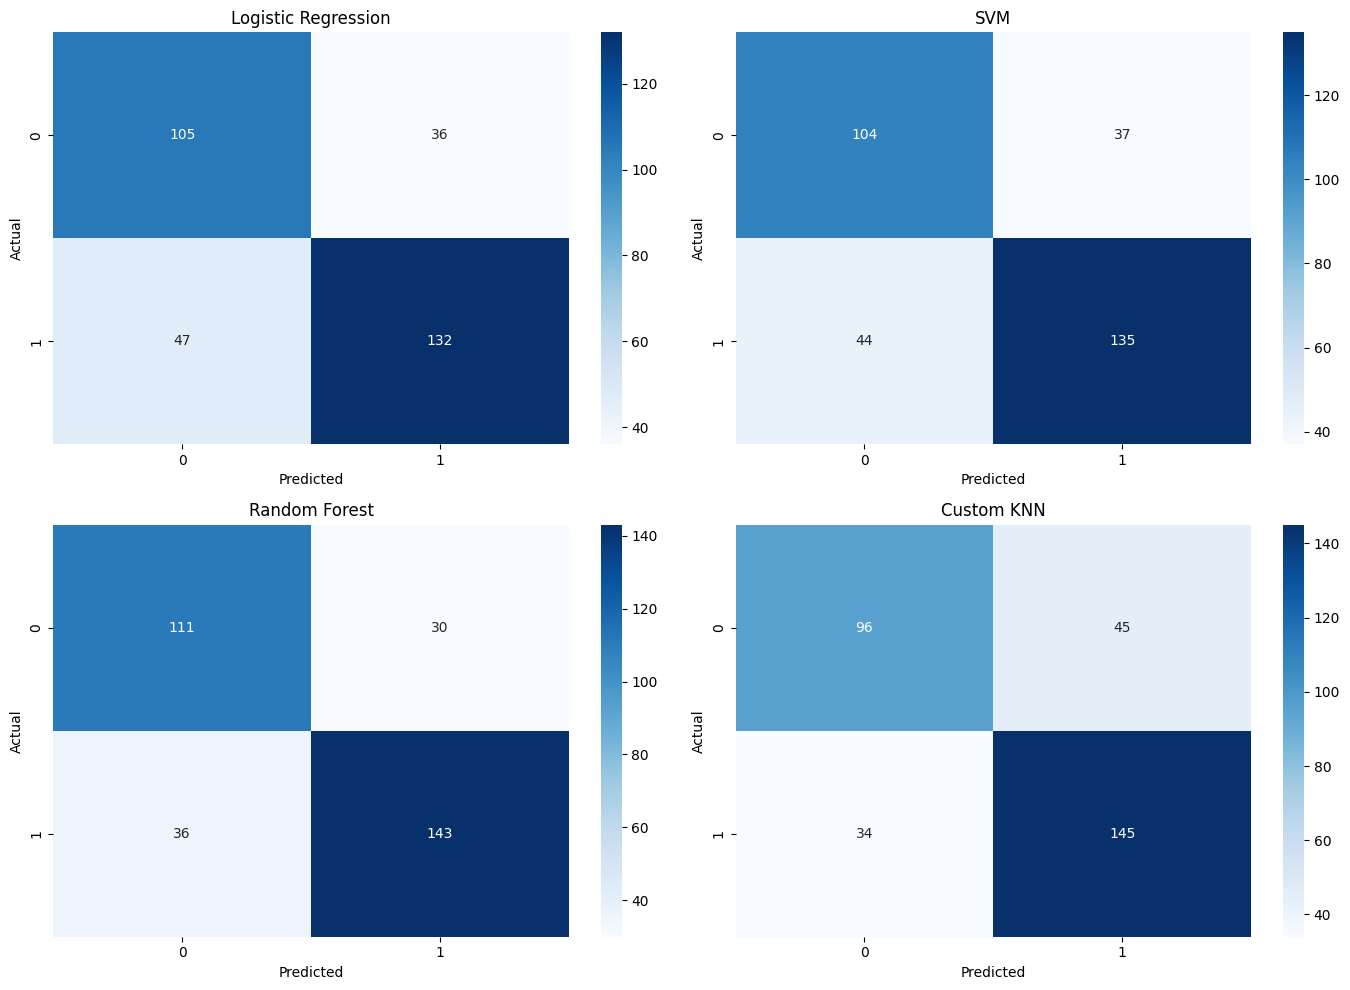

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Логистическая регрессия
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)

# SVM
svm = SVC(C=10, gamma=0.1, kernel='rbf')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# Custom KNN с k=1
custom_knn = CustomKNN(k=1)
custom_knn.fit(X_train_scaled, y_train)
y_pred_custom_knn = custom_knn.predict(X_test_scaled)

# Оценка моделей
models = {
    'Logistic Regression': (y_pred_log_reg, log_reg),
    'SVM': (y_pred_svm, svm),
    'Random Forest': (y_pred_rf, rf),
    'Custom KNN': (y_pred_custom_knn, custom_knn)
}

for name, (y_pred, model) in models.items():
    print(f'{name}:\n{classification_report(y_test, y_pred)}\n')

# Построение confusion matrices для всех моделей
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Логистическая регрессия
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Logistic Regression')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('SVM')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Random Forest')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# Custom KNN
cm_custom_knn = confusion_matrix(y_test, y_pred_custom_knn)
sns.heatmap(cm_custom_knn, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('Custom KNN')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

plt.tight_layout()
plt.show()